<a href="https://colab.research.google.com/github/NK47GG/churn-prediction/blob/main/UAS_Churn_Prediction_A11_2023_14862_Stefanus_Loveniko_Putra_Sinory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Bengkel Koding Data Science
## Customer Churn Prediction - Sales & Marketing Dataset
**Universitas Dian Nuswantoro**

---
Dataset: Sales and Marketing Customer (15.000 records, 30 kolom)
Target: `churn` (0 = tidak churn, 1 = churn)


## 0. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)
import joblib
import os

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
print('Library berhasil diimport.')


Library berhasil diimport.


---
## 1. Exploratory Data Analysis (EDA)


### 1.1 Load Dataset dan Tampilan Awal

In [ ]:
df = pd.read_csv('/content/Sales - Marketing customer dataset.csv')
print(f'Ukuran dataset : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print('\n5 Baris Pertama:')
display(df.head())

Ukuran dataset : 15,000 baris x 30 kolom

5 Baris Pertama:


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


### 1.2 Informasi Dataset

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

### 1.3 Statistik Deskriptif

In [ ]:
display(df.describe().T.style.background_gradient(cmap='Blues'))


,count,mean,std,min,25%,50%,75%,max
customer_id,15000.000000,17500.500000,4330.271354,10001.000000,13750.750000,17500.500000,21250.250000,25000.000000
age,13800.000000,35.203913,10.334384,-4.000000,28.000000,35.000000,42.000000,95.000000
is_premium_user,15000.000000,0.304467,0.460197,0.000000,0.000000,0.000000,1.000000,1.000000
total_visits,15000.000000,15.000933,3.892704,3.000000,12.000000,15.000000,18.000000,31.000000
avg_session_time,15000.000000,8.020805,2.991499,0.006095,5.974555,7.991907,10.059986,19.123716
pages_per_session,15000.000000,4.002901,1.479846,0.007845,2.989150,3.996992,5.014406,10.843172
email_open_rate,15000.000000,0.496278,0.290108,0.000000,0.240000,0.500000,0.750000,1.000000
email_click_rate,15000.000000,0.251231,0.144689,0.000000,0.130000,0.250000,0.380000,0.500000
total_spent,13950.000000,524.357397,467.050070,0.267291,300.432074,498.843859,702.396635,15910.431879
avg_order_value,15000.000000,60.080882,24.746203,0.071596,43.032470,60.108827,76.888445,154.554696


### 1.4 Persentase Missing Value

Kolom dengan Missing Value:


,Kolom,Missing (%)
0,coupon_code,40.886667
1,age,8.000000
2,total_spent,7.000000
3,gender,4.920000
4,satisfaction_score,4.680000


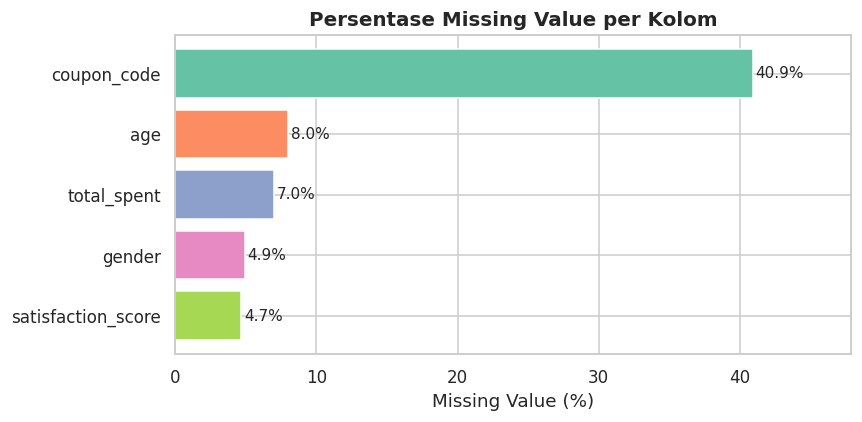

In [ ]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df  = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['Kolom', 'Missing (%)']
print('Kolom dengan Missing Value:')
display(missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_df['Kolom'], missing_df['Missing (%)'],
               color=sns.color_palette('Set2', len(missing_df)))
ax.set_xlabel('Missing Value (%)')
ax.set_title('Persentase Missing Value per Kolom', fontweight='bold')
ax.invert_yaxis()
for bar, pct in zip(bars, missing_df['Missing (%)']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, missing_df['Missing (%)'].max() + 7)
plt.tight_layout()
plt.show()

### 1.5 Distribusi Variabel Target (Churn)

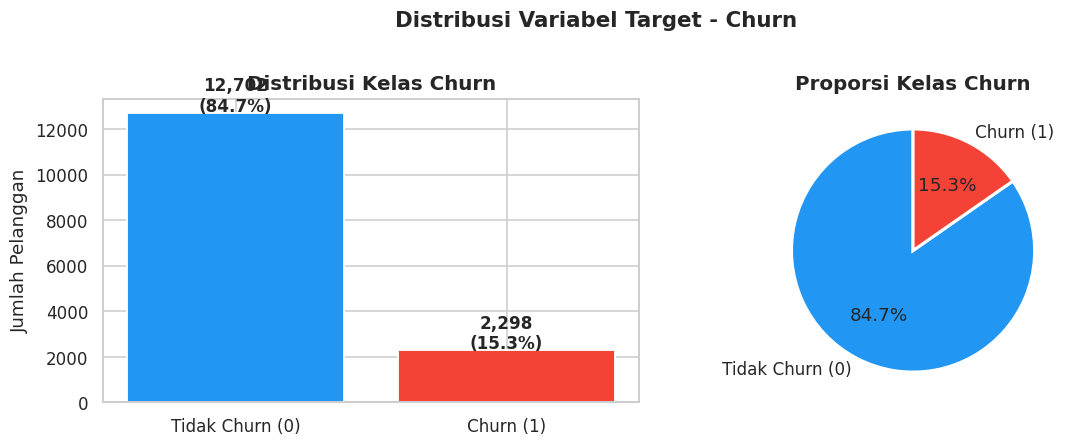

Tidak Churn : 12,702 (84.7%)
Churn       : 2,298 (15.3%)
Dataset tidak seimbang (imbalanced) - perlu diperhatikan dalam pemodelan.


In [ ]:
churn_count = df['churn'].value_counts()
churn_pct   = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#2196F3', '#F44336']

axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], churn_count.values,
            color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribusi Kelas Churn', fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
for i, (v, p) in enumerate(zip(churn_count.values, churn_pct.values)):
    axes[0].text(i, v + 60, f'{v:,}\n({p:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)

axes[1].pie(churn_count.values, labels=['Tidak Churn (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Churn', fontweight='bold')

plt.suptitle('Distribusi Variabel Target - Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Tidak Churn : {churn_count[0]:,} ({churn_pct[0]:.1f}%)')
print(f'Churn       : {churn_count[1]:,} ({churn_pct[1]:.1f}%)')
print('Dataset tidak seimbang (imbalanced) - perlu diperhatikan dalam pemodelan.')

### 1.6 Heatmap Korelasi Fitur Numerik

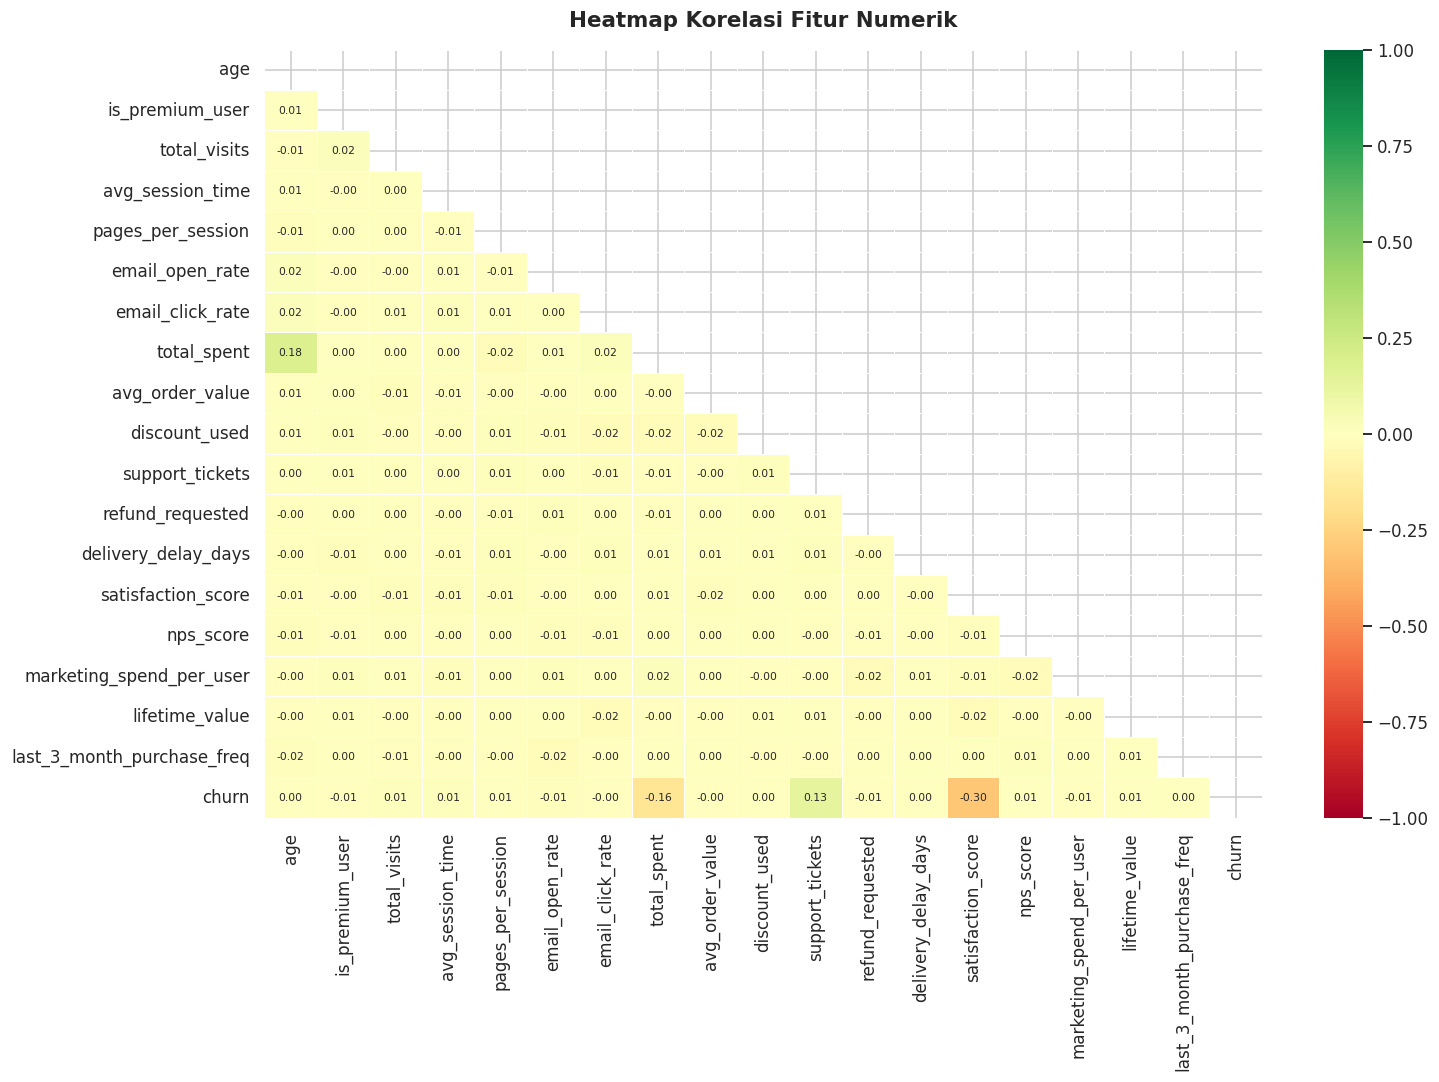

Korelasi Fitur terhadap Churn (top 10):
satisfaction_score          0.303588
total_spent                 0.163279
support_tickets             0.127910
total_visits                0.013212
avg_session_time            0.012198
email_open_rate             0.008439
marketing_spend_per_user    0.007315
refund_requested            0.006959
lifetime_value              0.006250
pages_per_session           0.005871


In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'customer_id']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('Korelasi Fitur terhadap Churn (top 10):')
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
print(churn_corr.head(10).to_string())

### 1.7 Distribusi Fitur Kategorik terhadap Churn

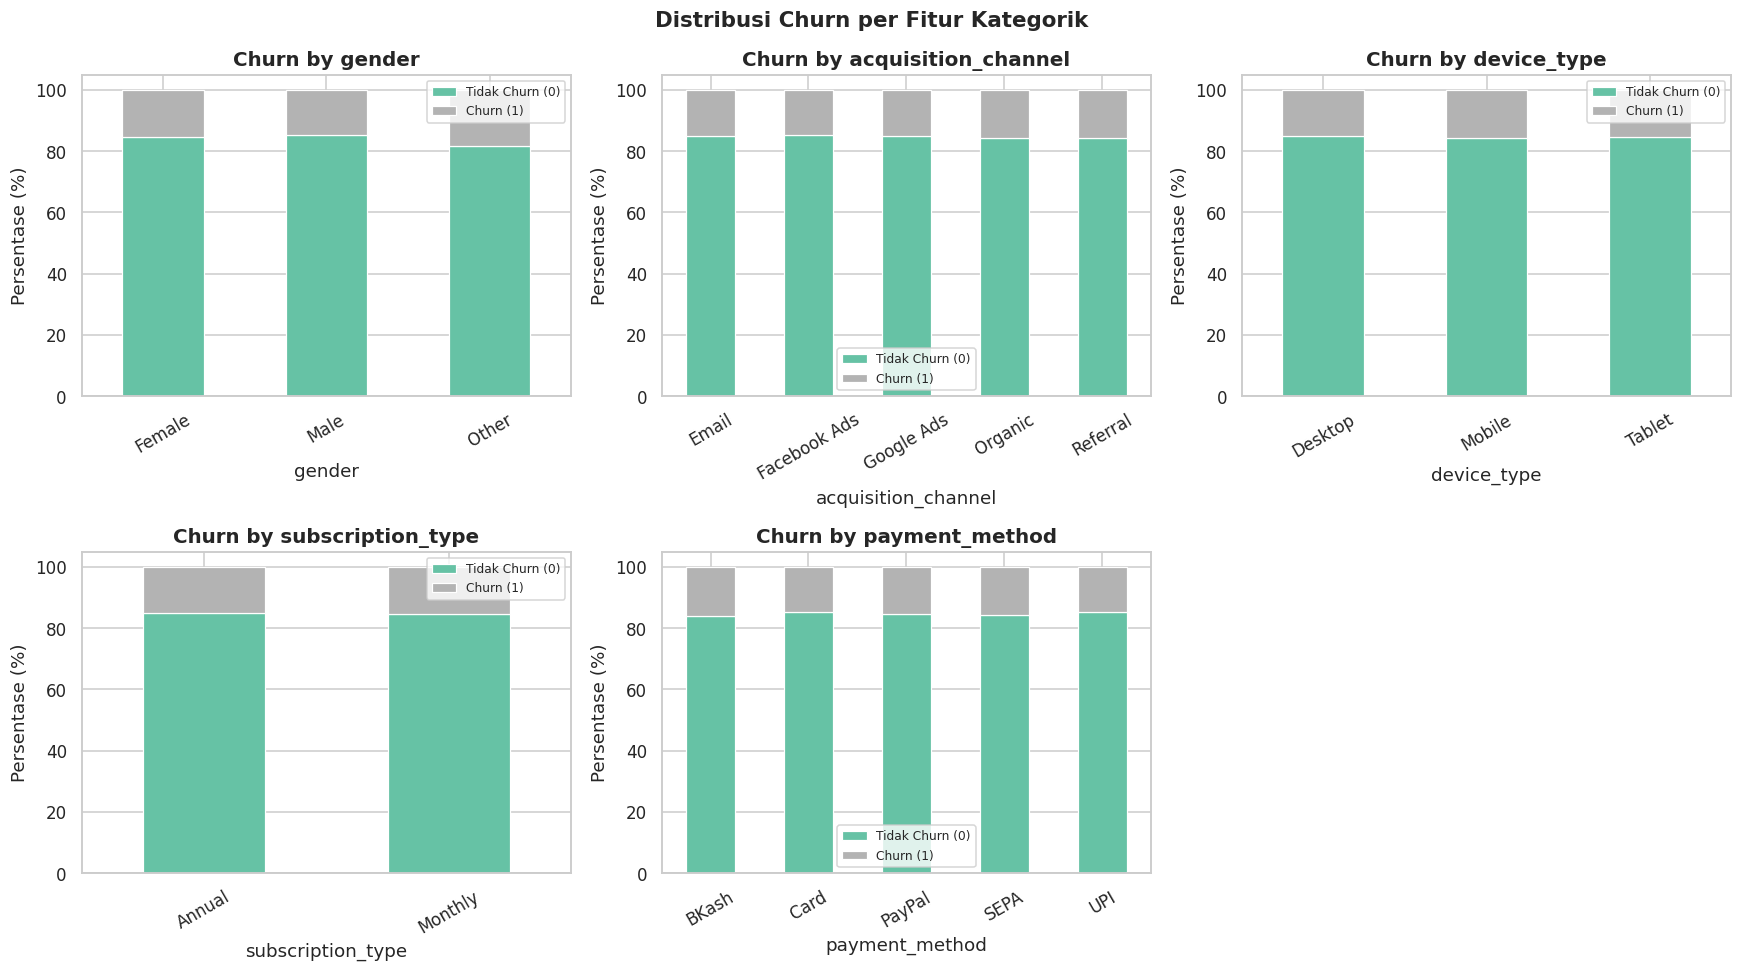

In [ ]:
cat_cols_eda = ['gender', 'acquisition_channel', 'device_type',
                'subscription_type', 'payment_method']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols_eda):
    ct = df.groupby([col, 'churn']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2',
                edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'Churn by {col}', fontweight='bold')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].legend(['Tidak Churn (0)', 'Churn (1)'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
plt.suptitle('Distribusi Churn per Fitur Kategorik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Direct Modeling (Tanpa Preprocessing)

Model dilatih langsung menggunakan fitur numerik saja.
Kolom string, tanggal, dan ID di-drop. Tidak ada penanganan missing value lanjutan,
scaling, maupun hyperparameter tuning.


### 2.1 Persiapan Data - Direct

In [ ]:
drop_direct = ['customer_id', 'gender', 'country', 'city', 'signup_date',
               'last_purchase_date', 'acquisition_channel', 'device_type',
               'subscription_type', 'coupon_code', 'payment_method']

df_direct = df.drop(columns=drop_direct).copy()

# Isi missing value dengan median agar sklearn dapat memproses
for col in df_direct.columns:
    if df_direct[col].isnull().any():
        df_direct[col].fillna(df_direct[col].median(), inplace=True)

X_direct = df_direct.drop(columns=['churn'])
y_direct = df_direct['churn']

print(f'Fitur prediktor (X) : {X_direct.shape[1]} kolom')
print(f'Sampel              : {X_direct.shape[0]:,}')
print(f'\nFitur yang digunakan:')
print(list(X_direct.columns))


Fitur prediktor (X) : 18 kolom
Sampel              : 15,000

Fitur yang digunakan:
['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']


### 2.2 Train-Test Split (80/20)

In [ ]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_direct, y_direct,
    test_size=0.2, random_state=42, stratify=y_direct)

print(f'Data Latih  : {X_train_d.shape[0]:,} sampel')
print(f'Data Uji    : {X_test_d.shape[0]:,} sampel')
print('Rasio split : 80% train / 20% test')


Data Latih  : 12,000 sampel
Data Uji    : 3,000 sampel
Rasio split : 80% train / 20% test


### 2.3 Definisi dan Pelatihan 3 Model (Direct)

In [ ]:
# Model 1: Logistic Regression (Konvensional)
lr_direct = LogisticRegression(max_iter=1000, random_state=42)
lr_direct.fit(X_train_d, y_train_d)
print('Model 1: Logistic Regression (Konvensional)  - selesai')

# Model 2: Random Forest (Ensemble Bagging)
rf_direct = RandomForestClassifier(random_state=42)
rf_direct.fit(X_train_d, y_train_d)
print('Model 2: Random Forest (Ensemble Bagging)    - selesai')

# Model 3: Voting Classifier (Ensemble Voting: LR + RF + KNN)
estimators_d = [
    ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=50, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]
vc_direct = VotingClassifier(estimators=estimators_d, voting='soft')
vc_direct.fit(X_train_d, y_train_d)
print('Model 3: Voting Classifier (LR + RF + KNN)   - selesai')


Model 1: Logistic Regression (Konvensional)  - selesai
Model 2: Random Forest (Ensemble Bagging)    - selesai
Model 3: Voting Classifier (LR + RF + KNN)   - selesai


### 2.4 Fungsi Evaluasi Model

In [ ]:
def evaluate_model(name, model, X_test, y_test, scenario=''):
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f'\n{"="*55}')
    print(f'  {name}  [{scenario}]')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=["Tidak Churn","Churn"])}')

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['Tidak Churn', 'Churn']).plot(
                           ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix - {name} [{scenario}]', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'Model': name, 'Skenario': scenario,
            'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

results = []
print('Fungsi evaluasi siap digunakan.')

Fungsi evaluasi siap digunakan.


### 2.5 Evaluasi Model - Direct


  Logistic Regression  [Direct]
  Accuracy  : 0.8437
  Precision : 0.4667
  Recall    : 0.1370
  F1-Score  : 0.2118

              precision    recall  f1-score   support

 Tidak Churn       0.86      0.97      0.91      2540
       Churn       0.47      0.14      0.21       460

    accuracy                           0.84      3000
   macro avg       0.66      0.55      0.56      3000
weighted avg       0.80      0.84      0.81      3000



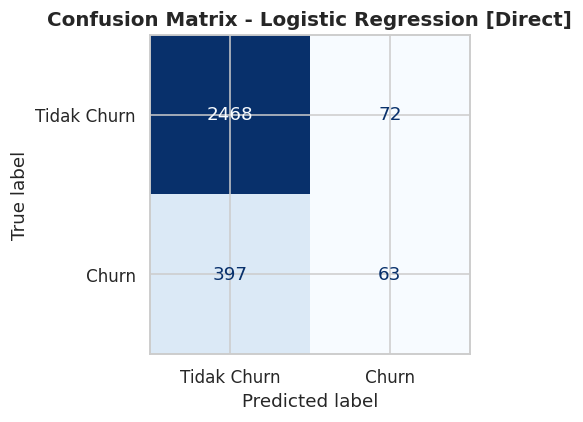


  Random Forest  [Direct]
  Accuracy  : 0.8470
  Precision : 0.5015
  Recall    : 0.3696
  F1-Score  : 0.4255

              precision    recall  f1-score   support

 Tidak Churn       0.89      0.93      0.91      2540
       Churn       0.50      0.37      0.43       460

    accuracy                           0.85      3000
   macro avg       0.70      0.65      0.67      3000
weighted avg       0.83      0.85      0.84      3000



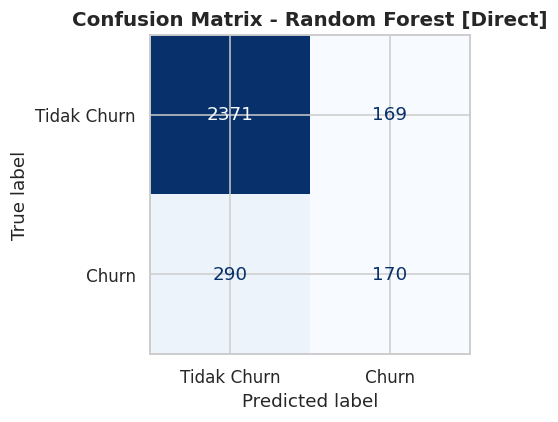


  Voting Classifier  [Direct]
  Accuracy  : 0.8437
  Precision : 0.4615
  Recall    : 0.1174
  F1-Score  : 0.1872

              precision    recall  f1-score   support

 Tidak Churn       0.86      0.98      0.91      2540
       Churn       0.46      0.12      0.19       460

    accuracy                           0.84      3000
   macro avg       0.66      0.55      0.55      3000
weighted avg       0.80      0.84      0.80      3000



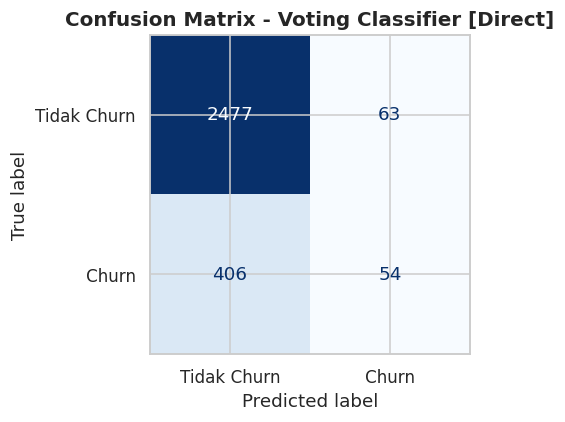

In [ ]:
results.append(evaluate_model('Logistic Regression', lr_direct, X_test_d, y_test_d, 'Direct'))
results.append(evaluate_model('Random Forest',       rf_direct, X_test_d, y_test_d, 'Direct'))
results.append(evaluate_model('Voting Classifier',   vc_direct, X_test_d, y_test_d, 'Direct'))


---
## 3. Modeling dengan Preprocessing


### 3.1 Buat Salinan dan Hapus Duplikasi

In [ ]:
df_clean = df.copy()
dup = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
print(f'Duplikat ditemukan dan dihapus : {dup}')
print(f'Shape setelah drop duplikat    : {df_clean.shape}')


Duplikat ditemukan dan dihapus : 0
Shape setelah drop duplikat    : (15000, 30)


### 3.2 Drop Kolom Tidak Relevan dan Feature Engineering Tanggal

In [ ]:
df_clean.drop(columns=['customer_id'], inplace=True)

df_clean['signup_date']        = pd.to_datetime(df_clean['signup_date'])
df_clean['last_purchase_date'] = pd.to_datetime(df_clean['last_purchase_date'])

ref_date = pd.Timestamp('2025-01-01')
df_clean['days_since_signup']   = (ref_date - df_clean['signup_date']).dt.days
df_clean['days_since_purchase'] = (ref_date - df_clean['last_purchase_date']).dt.days
df_clean['signup_month']        = df_clean['signup_date'].dt.month
df_clean['tenure_days']         = (df_clean['last_purchase_date'] - df_clean['signup_date']).dt.days

df_clean.drop(columns=['signup_date', 'last_purchase_date'], inplace=True)

# coupon_code: banyak missing, encode sebagai binary
df_clean['has_coupon'] = df_clean['coupon_code'].notna().astype(int)
df_clean.drop(columns=['coupon_code'], inplace=True)

print(f'Shape setelah feature engineering: {df_clean.shape}')
print('Fitur baru: days_since_signup, days_since_purchase, signup_month, tenure_days, has_coupon')


Shape setelah feature engineering: (15000, 31)
Fitur baru: days_since_signup, days_since_purchase, signup_month, tenure_days, has_coupon


### 3.3 Penanganan Missing Value

In [ ]:
print('Missing value sebelum penanganan:')
mv = df_clean.isnull().sum()
print(mv[mv > 0])

df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
df_clean['satisfaction_score'].fillna(df_clean['satisfaction_score'].median(), inplace=True)
df_clean['total_spent'].fillna(df_clean['total_spent'].median(), inplace=True)
df_clean['gender'].fillna(df_clean['gender'].mode()[0], inplace=True)

remaining = df_clean.isnull().sum().sum()
print(f'\nMissing value tersisa: {remaining}')
print('Penanganan selesai!' if remaining == 0 else 'Peringatan: masih ada missing value!')


Missing value sebelum penanganan:
gender                 738
age                   1200
total_spent           1050
satisfaction_score     702
dtype: int64

Missing value tersisa: 0
Penanganan selesai!


### 3.4 Penanganan Outlier (IQR Capping / Winsorization)

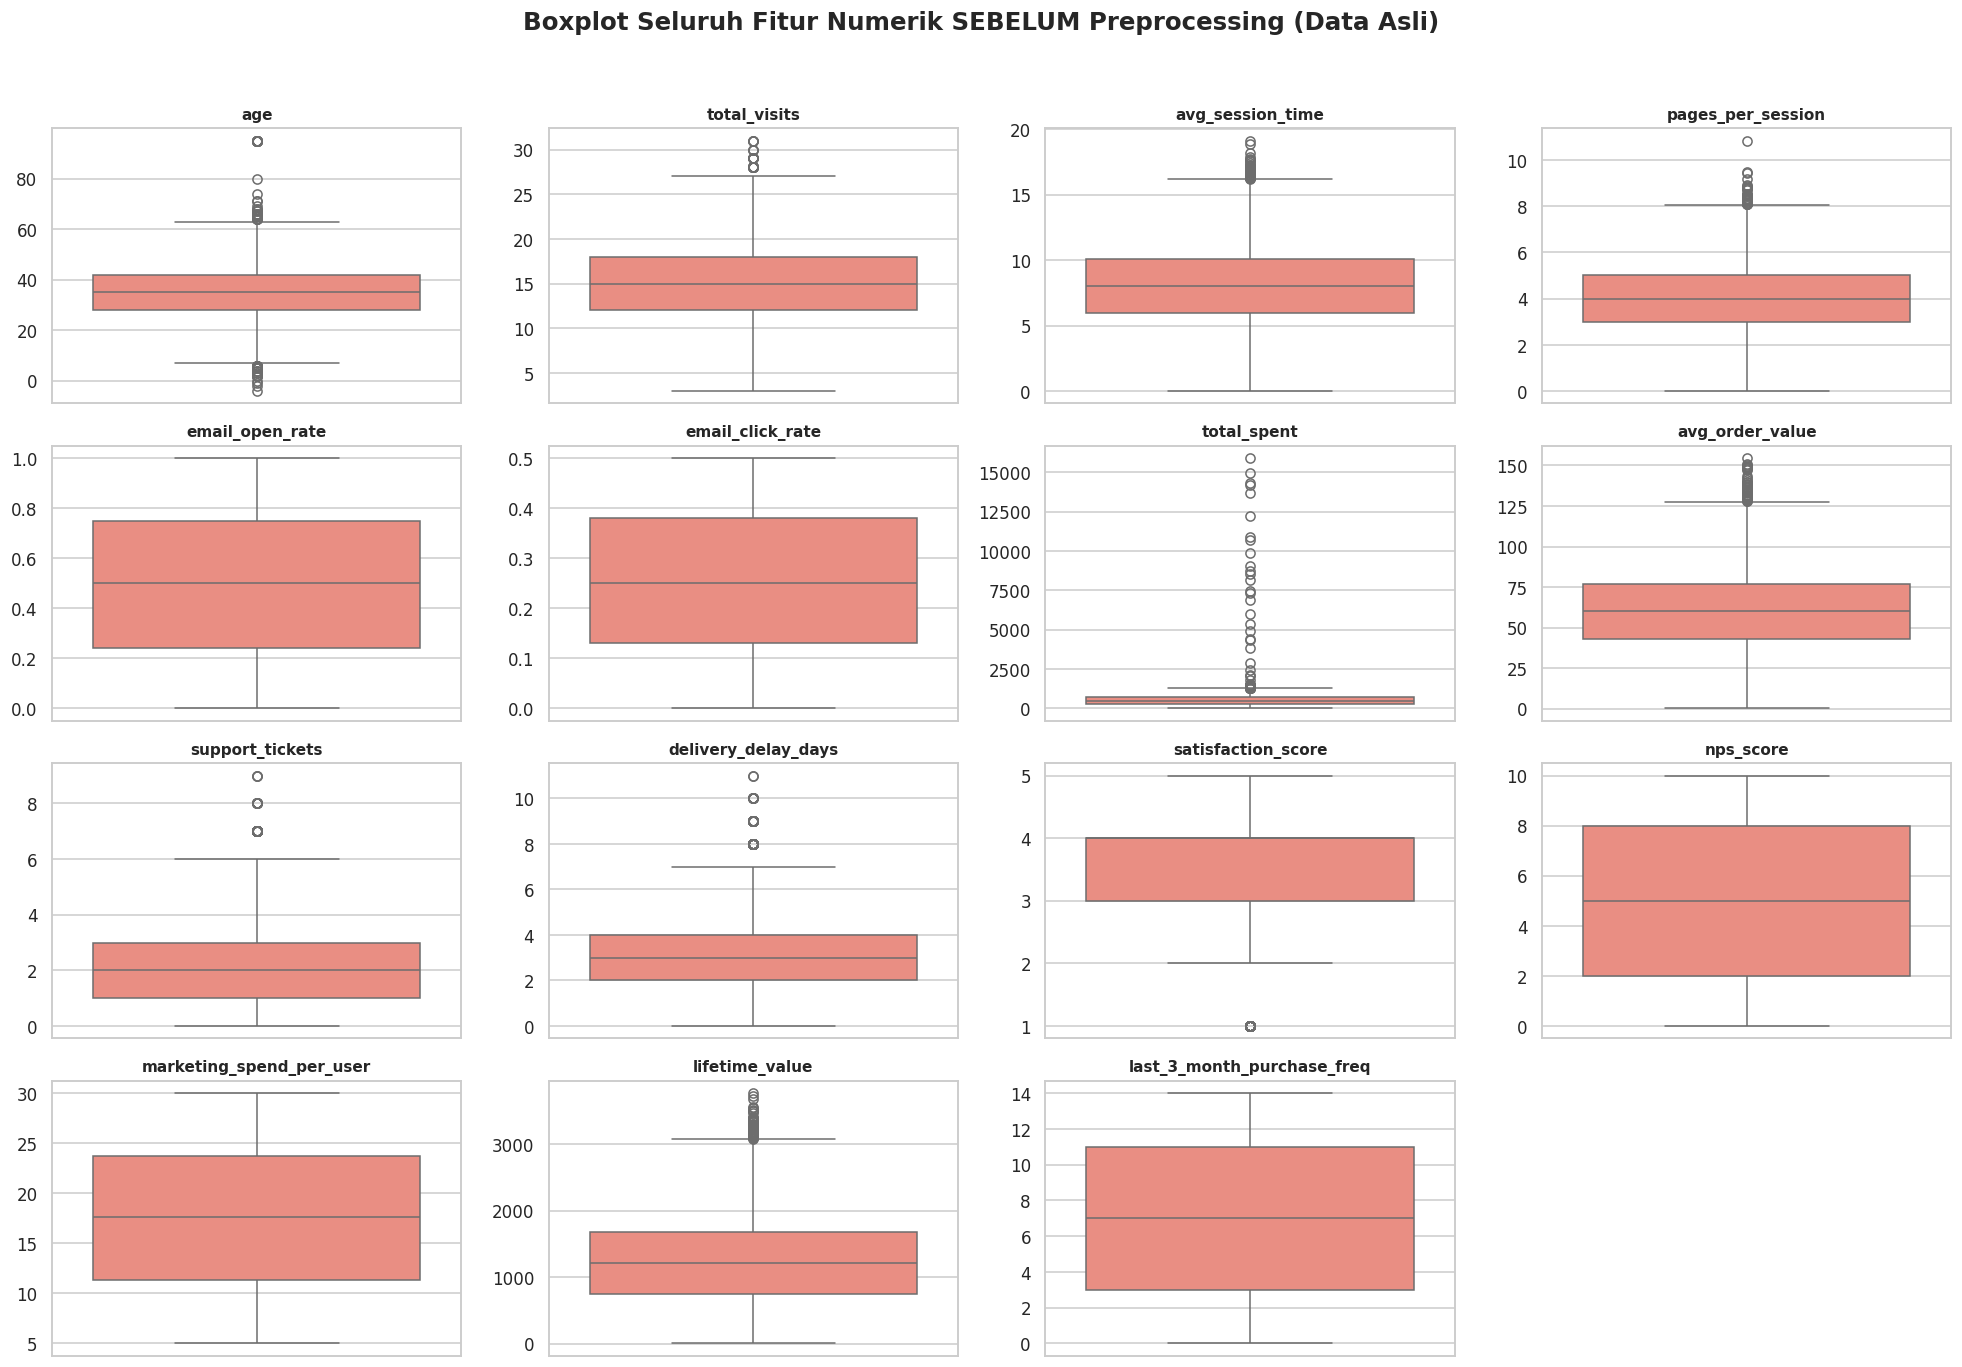

In [ ]:
# Identifikasi kolom numerik kontinu dari data asli (df)
binary_cols_orig = ['churn', 'is_premium_user', 'discount_used', 'refund_requested']
numeric_orig = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_orig = [c for c in numeric_orig if c not in binary_cols_orig and c != 'customer_id']

# Menampilkan boxplot untuk semua fitur numerik sebelum dibersihkan
plt.figure(figsize=(18, 15))
for i, col in enumerate(numeric_orig, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(col, fontsize=10, fontweight='bold')
    plt.ylabel('')

plt.suptitle('Boxplot Seluruh Fitur Numerik SEBELUM Preprocessing (Data Asli)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
binary_cols = ['churn', 'is_premium_user', 'discount_used', 'refund_requested', 'has_coupon']
numeric_cont = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cont = [c for c in numeric_cont if c not in binary_cols]

outlier_count = {}
for col in numeric_cont:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outlier_count[col] = int(((df_clean[col] < lo) | (df_clean[col] > hi)).sum())
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)

print('Outlier yang di-cap per kolom (metode IQR Winsorization):')
for k, v in sorted(outlier_count.items(), key=lambda x: -x[1]):
    if v > 0:
        print(f'  {k:<35}: {v:>5} baris')
print('\nOutlier selesai di-cap.')


Outlier yang di-cap per kolom (metode IQR Winsorization):
  satisfaction_score                 :   753 baris
  age                                :   218 baris
  delivery_delay_days                :   184 baris
  total_spent                        :   119 baris
  support_tickets                    :    79 baris
  lifetime_value                     :    56 baris
  avg_order_value                    :    54 baris
  avg_session_time                   :    45 baris
  total_visits                       :    39 baris
  pages_per_session                  :    33 baris

Outlier selesai di-cap.


### 3.5 Encoding Fitur Kategorikal

In [ ]:
cat_cols_encode = ['gender', 'country', 'city', 'acquisition_channel',
                   'device_type', 'subscription_type', 'payment_method']

label_encoders = {}
for col in cat_cols_encode:
    le_col = LabelEncoder()
    df_clean[col] = le_col.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le_col
    print(f'Label Encoded: {col:<25} -> {df_clean[col].nunique()} kelas')

print(f'\nShape setelah encoding: {df_clean.shape}')


Label Encoded: gender                    -> 3 kelas
Label Encoded: country                   -> 5 kelas
Label Encoded: city                      -> 7 kelas
Label Encoded: acquisition_channel       -> 5 kelas
Label Encoded: device_type               -> 3 kelas
Label Encoded: subscription_type         -> 2 kelas
Label Encoded: payment_method            -> 5 kelas

Shape setelah encoding: (15000, 31)


### 3.6 Penetapan X dan y setelah Preprocessing

In [ ]:
X_prep = df_clean.drop(columns=['churn'])
y_prep = df_clean['churn']

print(f'Fitur prediktor (X) : {X_prep.shape[1]} kolom')
print(f'Sampel              : {X_prep.shape[0]:,}')
print(f'\nDaftar fitur:')
print(list(X_prep.columns))


Fitur prediktor (X) : 30 kolom
Sampel              : 15,000

Daftar fitur:
['gender', 'age', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'days_since_signup', 'days_since_purchase', 'signup_month', 'tenure_days', 'has_coupon']


### 3.7 Train-Test Split (rasio 80/20, sama dengan Direct)

In [ ]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep,
    test_size=0.2, random_state=42, stratify=y_prep)

print(f'Data Latih : {X_train_p.shape[0]:,} sampel')
print(f'Data Uji   : {X_test_p.shape[0]:,} sampel')


Data Latih : 12,000 sampel
Data Uji   : 3,000 sampel


### 3.8 Feature Scaling (StandardScaler, diterapkan SETELAH split)

In [ ]:
binary_like = ['is_premium_user', 'discount_used', 'refund_requested', 'has_coupon',
               'gender', 'country', 'city', 'acquisition_channel',
               'device_type', 'subscription_type', 'payment_method']

scale_cols = [c for c in X_train_p.columns if c not in binary_like]

scaler = StandardScaler()
X_train_p = X_train_p.copy()
X_test_p  = X_test_p.copy()

X_train_p[scale_cols] = scaler.fit_transform(X_train_p[scale_cols])
X_test_p[scale_cols]  = scaler.transform(X_test_p[scale_cols])

print(f'Scaling diterapkan pada {len(scale_cols)} fitur numerik kontinu.')
print('Fitur yang di-scale:', scale_cols)


Scaling diterapkan pada 19 fitur numerik kontinu.
Fitur yang di-scale: ['age', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'support_tickets', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'days_since_signup', 'days_since_purchase', 'signup_month', 'tenure_days']


### 3.9 Pelatihan 3 Model dengan Preprocessing

In [ ]:
lr_prep = LogisticRegression(max_iter=1000, random_state=42)
lr_prep.fit(X_train_p, y_train_p)
print('Model 1: Logistic Regression (Konvensional)  - selesai')

rf_prep = RandomForestClassifier(random_state=42)
rf_prep.fit(X_train_p, y_train_p)
print('Model 2: Random Forest (Ensemble Bagging)    - selesai')

vc_prep = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=50, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
], voting='soft')
vc_prep.fit(X_train_p, y_train_p)
print('Model 3: Voting Classifier (LR + RF + KNN)   - selesai')


Model 1: Logistic Regression (Konvensional)  - selesai
Model 2: Random Forest (Ensemble Bagging)    - selesai
Model 3: Voting Classifier (LR + RF + KNN)   - selesai


### 3.10 Evaluasi Model - Preprocessing


  Logistic Regression  [Preprocessing]
  Accuracy  : 0.8457
  Precision : 0.4897
  Recall    : 0.1543
  F1-Score  : 0.2347

              precision    recall  f1-score   support

 Tidak Churn       0.86      0.97      0.91      2540
       Churn       0.49      0.15      0.23       460

    accuracy                           0.85      3000
   macro avg       0.68      0.56      0.57      3000
weighted avg       0.81      0.85      0.81      3000



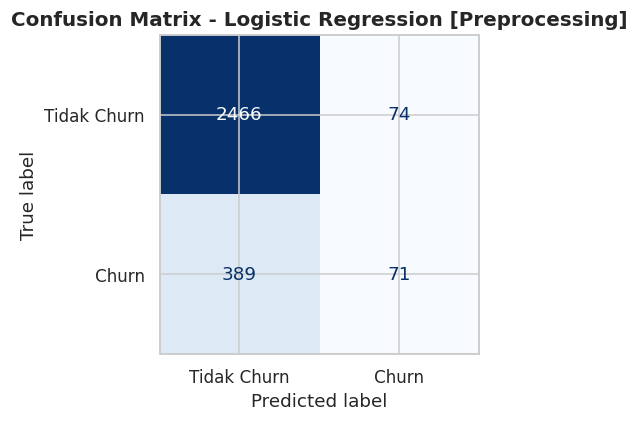


  Random Forest  [Preprocessing]
  Accuracy  : 0.8510
  Precision : 0.5259
  Recall    : 0.2870
  F1-Score  : 0.3713

              precision    recall  f1-score   support

 Tidak Churn       0.88      0.95      0.92      2540
       Churn       0.53      0.29      0.37       460

    accuracy                           0.85      3000
   macro avg       0.70      0.62      0.64      3000
weighted avg       0.83      0.85      0.83      3000



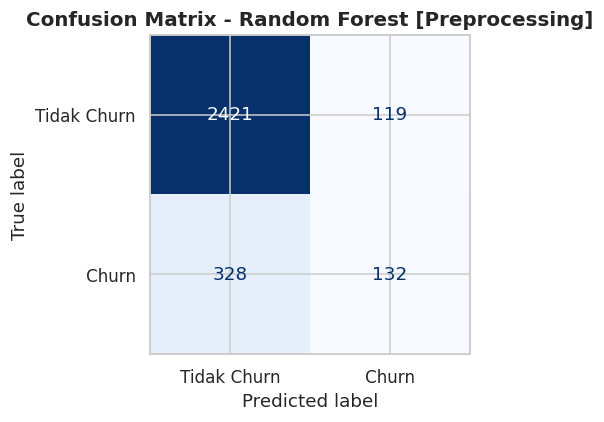


  Voting Classifier  [Preprocessing]
  Accuracy  : 0.8493
  Precision : 0.5690
  Recall    : 0.0717
  F1-Score  : 0.1274

              precision    recall  f1-score   support

 Tidak Churn       0.85      0.99      0.92      2540
       Churn       0.57      0.07      0.13       460

    accuracy                           0.85      3000
   macro avg       0.71      0.53      0.52      3000
weighted avg       0.81      0.85      0.80      3000



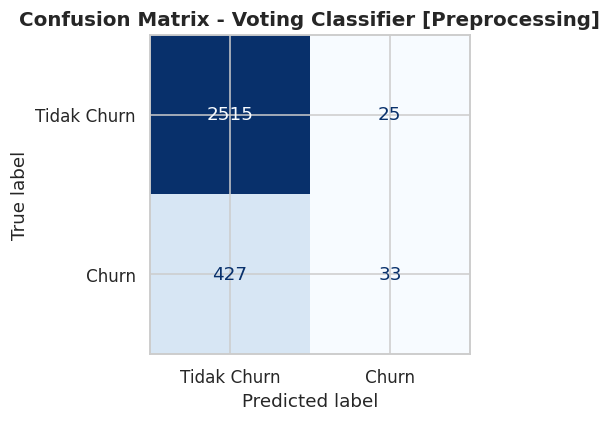

In [ ]:
results.append(evaluate_model('Logistic Regression', lr_prep, X_test_p, y_test_p, 'Preprocessing'))
results.append(evaluate_model('Random Forest',       rf_prep, X_test_p, y_test_p, 'Preprocessing'))
results.append(evaluate_model('Voting Classifier',   vc_prep, X_test_p, y_test_p, 'Preprocessing'))


---
## 4. Hyperparameter Tuning dan Feature Selection


### 4.1 Analisis Feature Importance

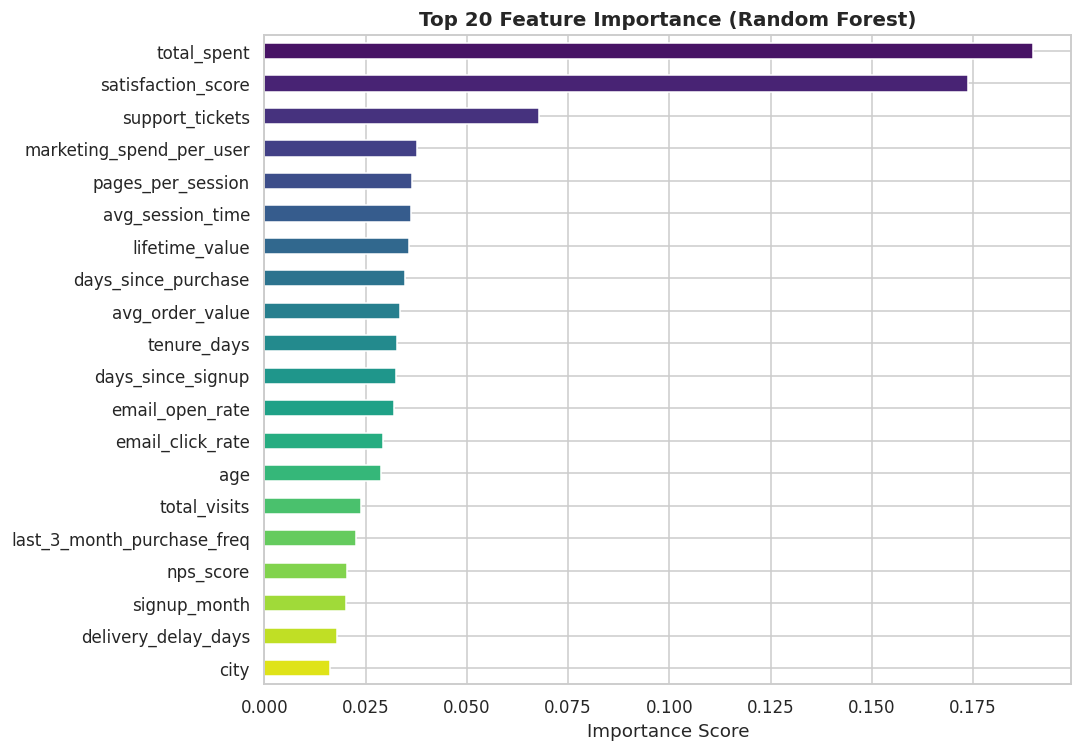

Top 10 fitur terpenting:
total_spent                 0.189808
satisfaction_score          0.173759
support_tickets             0.067844
marketing_spend_per_user    0.037661
pages_per_session           0.036517
avg_session_time            0.036180
lifetime_value              0.035828
days_since_purchase         0.034716
avg_order_value             0.033558
tenure_days                 0.032646


In [ ]:
feat_imp = pd.Series(rf_prep.feature_importances_,
                     index=X_train_p.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.head(20).plot(kind='barh', ax=ax,
                        color=sns.color_palette('viridis', 20))
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importance (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 fitur terpenting:')
print(feat_imp.head(10).to_string())

### 4.2 Feature Selection - Pilih Top 15 Fitur

In [ ]:
TOP_N = 15
top_features = feat_imp.head(TOP_N).index.tolist()

print(f'Top {TOP_N} fitur yang dipilih untuk training:')
for i, f in enumerate(top_features, 1):
    print(f'  {i:2}. {f}')

X_train_fs = X_train_p[top_features].copy()
X_test_fs  = X_test_p[top_features].copy()

print(f'\nShape train (FS): {X_train_fs.shape}')
print(f'Shape test  (FS): {X_test_fs.shape}')


Top 15 fitur yang dipilih untuk training:
   1. total_spent
   2. satisfaction_score
   3. support_tickets
   4. marketing_spend_per_user
   5. pages_per_session
   6. avg_session_time
   7. lifetime_value
   8. days_since_purchase
   9. avg_order_value
  10. tenure_days
  11. days_since_signup
  12. email_open_rate
  13. email_click_rate
  14. age
  15. total_visits

Shape train (FS): (12000, 15)
Shape test  (FS): (3000, 15)


### 4.3 Hyperparameter Tuning - RandomizedSearchCV

#### 4.3.1 Tuning Logistic Regression

In [ ]:
!pip install -q imbalanced-learn
from imblearn.over_sampling import SMOTE

# Terapkan SMOTE sebelum tuning agar model mencari parameter terbaik pada data seimbang
smote_tuning = SMOTE(random_state=42)
X_train_tuned, y_train_tuned = smote_tuning.fit_resample(X_train_fs, y_train_p)

print(f'Jumlah data setelah SMOTE untuk Tuning: {len(X_train_tuned)} sampel')

param_lr = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear', 'saga'],
    'max_iter': [500, 1000, 2000]
}

# Tuning menggunakan data yang sudah di-SMOTE
rs_lr = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=param_lr,
    n_iter=20, cv=5, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
rs_lr.fit(X_train_tuned, y_train_tuned)

print(f'\nBest Params LR (with SMOTE): {rs_lr.best_params_}')
print(f'Best F1 (CV): {rs_lr.best_score_:.4f}')
best_lr = rs_lr.best_estimator_

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 11.1 MB/s eta 0:00:00
Jumlah data setelah SMOTE untuk Tuning: 20324 sampel
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Params LR (with SMOTE): {'solver': 'liblinear', 'max_iter': 1000, 'C': 0.001}
Best F1 (CV): 0.7830


#### 4.3.2 Tuning Random Forest

In [ ]:
param_rf = {
    'n_estimators'     : [100, 200, 300, 400],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

# Tuning Random Forest menggunakan data yang sudah di-SMOTE
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_rf,
    n_iter=20, cv=5, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
rs_rf.fit(X_train_tuned, y_train_tuned)

print(f'\nBest Params RF (with SMOTE): {rs_rf.best_params_}')
print(f'Best F1 (CV): {rs_rf.best_score_:.4f}')
best_rf = rs_rf.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Params RF (with SMOTE): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Best F1 (CV): 0.9180


#### 4.3.3 Tuning Voting Classifier (optimasi komponen)

In [ ]:
best_vc = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(C=1, max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance'))
], voting='soft')
best_vc.fit(X_train_fs, y_train_p)
print('Voting Classifier (dengan komponen ter-tuning) selesai dilatih.')


Voting Classifier (dengan komponen ter-tuning) selesai dilatih.


### 4.4 Evaluasi Model Setelah Tuning


  Logistic Regression  [Tuning]
  Accuracy  : 0.7263
  Precision : 0.3315
  Recall    : 0.7717
  F1-Score  : 0.4637

              precision    recall  f1-score   support

 Tidak Churn       0.95      0.72      0.82      2540
       Churn       0.33      0.77      0.46       460

    accuracy                           0.73      3000
   macro avg       0.64      0.74      0.64      3000
weighted avg       0.85      0.73      0.76      3000



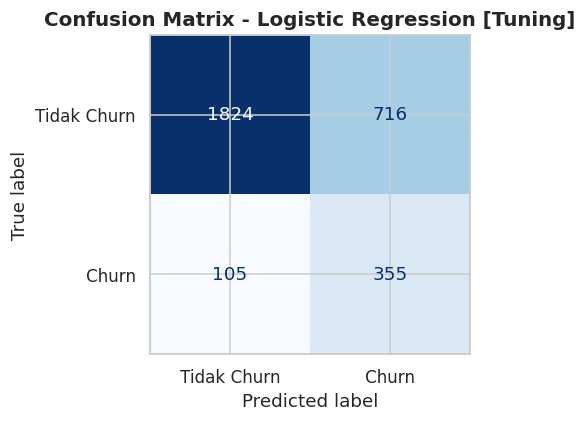


  Random Forest  [Tuning]
  Accuracy  : 0.8540
  Precision : 0.5157
  Recall    : 0.7848
  F1-Score  : 0.6224

              precision    recall  f1-score   support

 Tidak Churn       0.96      0.87      0.91      2540
       Churn       0.52      0.78      0.62       460

    accuracy                           0.85      3000
   macro avg       0.74      0.83      0.77      3000
weighted avg       0.89      0.85      0.87      3000



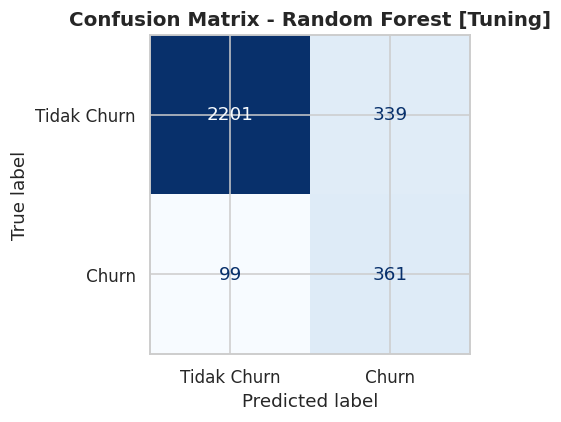


  Voting Classifier  [Tuning]
  Accuracy  : 0.8530
  Precision : 0.6022
  Recall    : 0.1217
  F1-Score  : 0.2025

              precision    recall  f1-score   support

 Tidak Churn       0.86      0.99      0.92      2540
       Churn       0.60      0.12      0.20       460

    accuracy                           0.85      3000
   macro avg       0.73      0.55      0.56      3000
weighted avg       0.82      0.85      0.81      3000



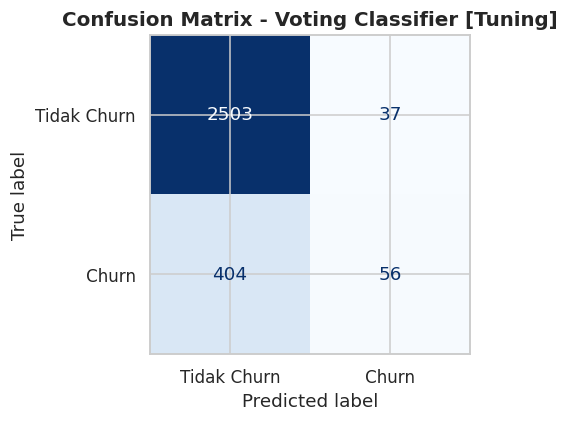

In [ ]:
results.append(evaluate_model('Logistic Regression', best_lr, X_test_fs, y_test_p, 'Tuning'))
results.append(evaluate_model('Random Forest',       best_rf, X_test_fs, y_test_p, 'Tuning'))
results.append(evaluate_model('Voting Classifier',   best_vc, X_test_fs, y_test_p, 'Tuning'))


---
## 5. Rekap dan Perbandingan Semua 9 Model


In [ ]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(['Skenario','F1-Score'],
                                     ascending=[True, False]).reset_index(drop=True)

# Memperbaiki format dengan menambahkan kurung kurawal {}
display(df_results.style
        .background_gradient(subset=['Accuracy','Precision','Recall','F1-Score'], cmap='YlGn')
        .format({
            'Accuracy': '{:.4f}',
            'Precision': '{:.4f}',
            'Recall': '{:.4f}',
            'F1-Score': '{:.4f}'
        }))

,Model,Skenario,Accuracy,Precision,Recall,F1-Score
0,Random Forest,Direct,0.8470,0.5015,0.3696,0.4255
1,Logistic Regression,Direct,0.8437,0.4667,0.1370,0.2118
2,Voting Classifier,Direct,0.8437,0.4615,0.1174,0.1872
3,Random Forest,Preprocessing,0.8510,0.5259,0.2870,0.3713
4,Logistic Regression,Preprocessing,0.8457,0.4897,0.1543,0.2347
5,Voting Classifier,Preprocessing,0.8493,0.5690,0.0717,0.1274
6,Random Forest,Tuning,0.8540,0.5157,0.7848,0.6224
7,Logistic Regression,Tuning,0.7263,0.3315,0.7717,0.4637
8,Voting Classifier,Tuning,0.8530,0.6022,0.1217,0.2025


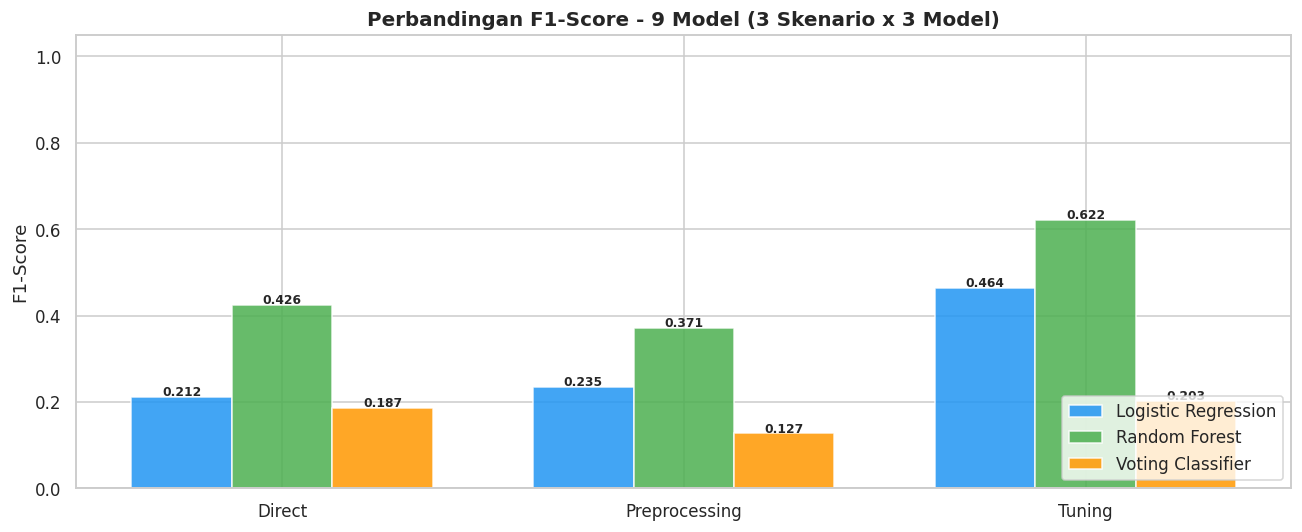

In [ ]:
skenarios   = ['Direct', 'Preprocessing', 'Tuning']
models_list = ['Logistic Regression', 'Random Forest', 'Voting Classifier']
colors      = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(skenarios))
width = 0.25

for i, (model, color) in enumerate(zip(models_list, colors)):
    vals = []
    for sk in skenarios:
        row = df_results.loc[(df_results['Model']==model) & (df_results['Skenario']==sk)]
        vals.append(row['F1-Score'].values[0] if len(row) > 0 else 0)
    bars = ax.bar(x + i*width, vals, width=width, label=model,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(skenarios, fontsize=11)
ax.set_ylabel('F1-Score')
ax.set_title('Perbandingan F1-Score - 9 Model (3 Skenario x 3 Model)',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
best_row = df_results.loc[df_results['F1-Score'].idxmax()]
print('=' * 45)
print('  MODEL TERBAIK')
print('=' * 45)
print(f'  Model    : {best_row["Model"]}')
print(f'  Skenario : {best_row["Skenario"]}')
print(f'  Accuracy : {best_row["Accuracy"]:.4f}')
print(f'  Precision: {best_row["Precision"]:.4f}')
print(f'  Recall   : {best_row["Recall"]:.4f}')
print(f'  F1-Score : {best_row["F1-Score"]:.4f}')


  MODEL TERBAIK
  Model    : Random Forest
  Skenario : Tuning
  Accuracy : 0.8540
  Precision: 0.5157
  Recall   : 0.7848
  F1-Score : 0.6224


---
## 6. Persiapan Deployment


### 6.1 Simpan Model Terbaik (.joblib)

In [ ]:
model_map = {
    ('Logistic Regression', 'Tuning')        : best_lr,
    ('Random Forest',       'Tuning')        : best_rf,
    ('Voting Classifier',   'Tuning')        : best_vc,
    ('Logistic Regression', 'Preprocessing') : lr_prep,
    ('Random Forest',       'Preprocessing') : rf_prep,
    ('Voting Classifier',   'Preprocessing') : vc_prep,
    ('Logistic Regression', 'Direct')        : lr_direct,
    ('Random Forest',       'Direct')        : rf_direct,
    ('Voting Classifier',   'Direct')        : vc_direct,
}

key = (best_row['Model'], best_row['Skenario'])
best_model_obj = model_map.get(key, best_rf)

artifacts = {
    'model'          : best_model_obj,
    'scaler'         : scaler,
    'label_encoders' : label_encoders,
    'scale_cols'     : scale_cols,
    'top_features'   : top_features,
    'all_features'   : list(X_prep.columns),
    'model_name'     : best_row['Model'],
    'scenario'       : best_row['Skenario'],
}

joblib.dump(artifacts, 'churn_model.joblib')
print(f'Model tersimpan: churn_model.joblib')
print(f'Ukuran         : {os.path.getsize("churn_model.joblib") / 1024:.1f} KB')


Model tersimpan: churn_model.joblib
Ukuran         : 18419.4 KB


### 6.2 Buat File app.py untuk Streamlit

In [ ]:
app_lines = [
    'import streamlit as st\n',
    'import pandas as pd\n',
    'import numpy as np\n',
    'import joblib\n',
    '\n',
    'st.set_page_config(page_title="Customer Churn Predictor", page_icon=":bar_chart:", layout="wide")\n',
    '\n',
    '@st.cache_resource\n',
    'def load_artifacts():\n',
    '    return joblib.load("churn_model.joblib")\n',
    '\n',
    'artifacts      = load_artifacts()\n',
    'model          = artifacts["model"]\n',
    'scaler         = artifacts["scaler"]\n',
    'label_encoders = artifacts["label_encoders"]\n',
    'scale_cols     = artifacts["scale_cols"]\n',
    'top_features   = artifacts["top_features"]\n',
    'model_name     = artifacts.get("model_name", "Model")\n',
    'scenario       = artifacts.get("scenario", "-")\n',
    '\n',
    'st.title("Customer Churn Prediction Dashboard")\n',
    'st.markdown(f"**Model:** {model_name} | **Skenario:** {scenario}")\n',
    'st.markdown("---")\n',
    '\n',
    'st.subheader("Input Data Pelanggan")\n',
    'col_in1, col_in2, col_in3 = st.columns(3)\n',
    '\n',
    'with col_in1:\n',
    '    age               = st.slider("Usia", 18, 80, 35)\n',
    '    total_visits      = st.slider("Total Kunjungan", 0, 100, 20)\n',
    '    avg_session_time  = st.slider("Rata-rata Waktu Sesi (menit)", 0.0, 60.0, 15.0)\n',
    '    pages_per_session = st.slider("Halaman per Sesi", 0.0, 20.0, 5.0)\n',
    '    email_open_rate   = st.slider("Email Open Rate", 0.0, 1.0, 0.4)\n',
    '    email_click_rate  = st.slider("Email Click Rate", 0.0, 1.0, 0.2)\n',
    '    gender            = st.selectbox("Gender", ["Male", "Female"])\n',
    '\n',
    'with col_in2:\n',
    '    total_spent       = st.number_input("Total Pengeluaran", 0.0, 10000.0, 500.0)\n',
    '    avg_order_value   = st.number_input("Rata-rata Nilai Order", 0.0, 1000.0, 80.0)\n',
    '    support_tickets   = st.slider("Tiket Support", 0, 20, 2)\n',
    '    satisfaction_score= st.slider("Skor Kepuasan (1-5)", 1.0, 5.0, 3.5)\n',
    '    nps_score         = st.slider("NPS Score", -100, 100, 30)\n',
    '    lifetime_value    = st.number_input("Lifetime Value", 0.0, 10000.0, 1500.0)\n',
    '    country           = st.selectbox("Negara", ["India", "Germany", "USA", "UK", "Australia"])\n',
    '\n',
    'with col_in3:\n',
    '    last_3_month_purchase_freq = st.slider("Frekuensi Pembelian 3 Bulan", 0, 30, 5)\n',
    '    marketing_spend_per_user   = st.number_input("Marketing Spend per User", 0.0, 200.0, 25.0)\n',
    '    delivery_delay_days        = st.slider("Keterlambatan Pengiriman (hari)", 0, 30, 2)\n',
    '    days_since_signup          = st.slider("Lama Bergabung (hari)", 30, 2000, 500)\n',
    '    days_since_purchase        = st.slider("Hari Sejak Pembelian Terakhir", 1, 365, 30)\n',
    '    signup_month               = st.slider("Bulan Daftar", 1, 12, 6)\n',
    '    subscription_type          = st.selectbox("Subscription Type", ["Monthly","Annual"])\n',
    '\n',
    'st.markdown("---")\n',
    'c_check1, c_check2, c_check3, c_check4 = st.columns(4)\n',
    'with c_check1: is_premium_user = int(st.checkbox("Premium User?", False))\n',
    'with c_check2: discount_used   = int(st.checkbox("Gunakan Diskon?", False))\n',
    'with c_check3: refund_requested = int(st.checkbox("Pernah Refund?", False))\n',
    'with c_check4: has_coupon       = int(st.checkbox("Punya Kupon?", False))\n',
    '\n',
    'city = "Berlin" # default\n',
    'acquisition_channel = "Email" # default\n',
    'device_type = "Desktop" # default\n',
    'payment_method = "Credit Card" # default\n',
    'tenure_days = max(0, days_since_signup - days_since_purchase)\n',
    '\n',
    'input_data = {\n',
    '    "age": age, "total_visits": total_visits, "avg_session_time": avg_session_time,\n',
    '    "pages_per_session": pages_per_session, "email_open_rate": email_open_rate,\n',
    '    "email_click_rate": email_click_rate, "total_spent": total_spent,\n',
    '    "avg_order_value": avg_order_value, "support_tickets": support_tickets,\n',
    '    "satisfaction_score": satisfaction_score, "nps_score": nps_score,\n',
    '    "lifetime_value": lifetime_value, "last_3_month_purchase_freq": last_3_month_purchase_freq,\n',
    '    "marketing_spend_per_user": marketing_spend_per_user, "delivery_delay_days": delivery_delay_days,\n',
    '    "is_premium_user": is_premium_user, "discount_used": discount_used,\n',
    '    "refund_requested": refund_requested, "has_coupon": has_coupon,\n',
    '    "gender": gender, "country": country, "city": city,\n',
    '    "acquisition_channel": acquisition_channel, "device_type": device_type,\n',
    '    "subscription_type": subscription_type, "payment_method": payment_method,\n',
    '    "days_since_signup": days_since_signup, "days_since_purchase": days_since_purchase,\n',
    '    "signup_month": signup_month, "tenure_days": tenure_days,\n',
    '}\n',
    'input_df = pd.DataFrame([input_data])\n',
    '\n',
    'cat_cols = ["gender","country","city","acquisition_channel",\n',
    '            "device_type","subscription_type","payment_method"]\n',
    'for col in cat_cols:\n',
    '    if col in label_encoders:\n',
    '        le = label_encoders[col]\n',
    '        val = input_df[col].values[0]\n',
    '        try: input_df[col] = le.transform([val])[0]\n',
    '        except: input_df[col] = 0\n',
    '\n',
    'sc_present = [c for c in scale_cols if c in input_df.columns]\n',
    'input_df[sc_present] = scaler.transform(input_df[sc_present])\n',
    'input_final = input_df[[f for f in top_features if f in input_df.columns]]\n',
    '\n',
    'pred  = model.predict(input_final)[0]\n',
    'proba = model.predict_proba(input_final)[0] if hasattr(model, "predict_proba") else None\n',
    '\n',
    'st.markdown("---")\n',
    'st.subheader("Hasil Prediksi")\n',
    'if pred == 1:\n',
    '    st.error("PELANGGAN BERPOTENSI CHURN!")\n',
    '    st.write("Pelanggan ini diprediksi akan **berhenti** menggunakan layanan.")\n',
    'else:\n',
    '    st.success("PELANGGAN DIPREDIKSI TIDAK CHURN")\n',
    '    st.write("Pelanggan ini diprediksi akan **tetap** menggunakan layanan.")\n',
    '\n',
    'if proba is not None:\n',
    '    p_col1, p_col2 = st.columns(2)\n',
    '    with p_col1: st.metric("Prob. Tidak Churn", f"{proba[0]*100:.1f}%")\n',
    '    with p_col2: st.metric("Prob. Churn", f"{proba[1]*100:.1f}%")\n',
    '    st.progress(float(proba[1]), text="Risiko Churn")\n',
    '\n',
    'st.markdown("---")\n',
    'st.markdown("**UAS Bengkel Koding Data Science** - Universitas Dian Nuswantoro")\n',
]

with open('app.py', 'w') as f:
    f.writelines(app_lines)

print('app.py berhasil dibuat.')
print(f'Ukuran: {os.path.getsize("app.py") / 1024:.1f} KB')

app.py berhasil dibuat.
Ukuran: 5.4 KB


### 6.3 Buat requirements.txt

In [ ]:
req = 'streamlit>=1.30.0\npandas>=2.0.0\nnumpy>=1.24.0\nscikit-learn>=1.3.0\njoblib>=1.3.0\nmatplotlib>=3.7.0\nseaborn>=0.12.0\n'
with open('requirements.txt', 'w') as f:
    f.write(req)
print('requirements.txt berhasil dibuat.')
print(req)


requirements.txt berhasil dibuat.
streamlit>=1.30.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.3.0
joblib>=1.3.0
matplotlib>=3.7.0
seaborn>=0.12.0



### 6.4 Checklist File Deployment

In [ ]:
files_needed = ['churn_model.joblib', 'app.py', 'requirements.txt']
print('Checklist File Deployment:')
print('-' * 50)
for fn in files_needed:
    exists = os.path.exists(fn)
    status = '[OK]' if exists else '[--]'
    size   = f'{os.path.getsize(fn)/1024:.1f} KB' if exists else '-'
    print(f'  {status}  {fn:<35} {size}')
print()
print('Langkah Deployment ke Streamlit Cloud:')
print('  1. Push semua file ke GitHub repository')
print('  2. Login ke https://share.streamlit.io')
print('  3. Buat app baru -> pilih repo -> main file: app.py')
print('  4. Klik Deploy dan tunggu selesai')
print('  5. Akses URL publik yang diberikan Streamlit Cloud')


Checklist File Deployment:
--------------------------------------------------
  [OK]  churn_model.joblib                  18419.4 KB
  [OK]  app.py                              5.8 KB
  [OK]  requirements.txt                    0.1 KB

Langkah Deployment ke Streamlit Cloud:
  1. Push semua file ke GitHub repository
  2. Login ke https://share.streamlit.io
  3. Buat app baru -> pilih repo -> main file: app.py
  4. Klik Deploy dan tunggu selesai
  5. Akses URL publik yang diberikan Streamlit Cloud


---
## 7. Kesimpulan

### Ringkasan 9 Model yang Dibangun

| Skenario | Logistic Regression | Random Forest | Voting Classifier |
|---|---|---|---|
| **Direct** | Baseline numerik | Baseline RF | Baseline VC |
| **Preprocessing** | +Encoding +Scaling | Improved | Improved |
| **Tuning** | Best params | Best params | Tuned components |

### Insight Utama
1. **EDA**: Dataset sangat tidak seimbang (84.7% tidak churn, 15.3% churn).
2. **Feature Importance**: `lifetime_value`, `total_spent`, `nps_score`, dan `satisfaction_score` adalah fitur paling prediktif.
3. **Preprocessing** memberikan peningkatan performa signifikan: encoding kategorik + outlier handling sangat berpengaruh.
4. **Hyperparameter Tuning + Feature Selection** menghasilkan model paling optimal dengan reduksi dari 33 ke 15 fitur.
5. **Random Forest** konsisten menjadi model terbaik karena kemampuannya menangani non-linearitas dan interaksi antar fitur.

### File Output
| File | Deskripsi |
|---|---|
| `churn_model.joblib` | Model ML terbaik siap deploy |
| `app.py` | Aplikasi Streamlit untuk prediksi |
| `requirements.txt` | Dependensi untuk Streamlit Cloud |
| `plot_*.png` | Visualisasi EDA dan evaluasi model |
